# 047 Final. Counterfactual: rerank vs wide MMR-rerank на 100 вопросах с LLM-as-a-judge

Финальный прогон после ablation.

Сравниваются только два метода:

1. `rerank`: `dense top-20 → rerank → final top-5`
2. `wide_mmr_l05_top80_final7`: `dense top-80 → MMR top-20, λ=0.5 → rerank → final top-7`

Проверяются уровни:

- `0` — чистая база;
- `40` — counterfactual replacement 40%;
- `80` — counterfactual replacement 80%.

Включён `LLM-as-a-judge`:

- `correctness_score`;
- `faithfulness_score`.

Поддерживается несколько Groq-ключей и кэширование, чтобы можно было продолжать после лимитов.


In [36]:
!pip -q install qdrant-client sentence-transformers groq tqdm pandas numpy matplotlib scikit-learn

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import os
import re
import json
import time
import random
import traceback
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity

from groq import Groq

random.seed(42)
np.random.seed(42)

## 1. Пути и настройки эксперимента

In [39]:
BASE_DIR = Path("/content/drive/MyDrive/rag_experiment")
ARTIFACTS_DIR = BASE_DIR / "artifacts"

QUESTIONS_PATH = ARTIFACTS_DIR / "questions.json"
GOLD_MAPPING_PATH = ARTIFACTS_DIR / "gold_mapping.json"

OUT_DIR = ARTIFACTS_DIR / "experiments" / "047_counterfactual_wide_mmr_final_100_judge"
CACHE_DIR = OUT_DIR / "cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUT_DIR:", OUT_DIR)
print("CACHE_DIR:", CACHE_DIR)

BASE_DIR: /content/drive/MyDrive/rag_experiment
OUT_DIR: /content/drive/MyDrive/rag_experiment/artifacts/experiments/047_counterfactual_wide_mmr_final_100_judge
CACHE_DIR: /content/drive/MyDrive/rag_experiment/artifacts/experiments/047_counterfactual_wide_mmr_final_100_judge/cache


In [ ]:
# === Qdrant ===
QDRANT_URL = " "
QDRANT_API_KEY = " "


COLLECTIONS = {
    0: "rag_clean",
    40: "rag_noisy_counterfactual_replace_40",
    80: "rag_noisy_counterfactual_replace_80",
}

client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
print("Qdrant URL:", QDRANT_URL)
print("Expected collections:", COLLECTIONS)

Qdrant URL: https://92fb2201-8122-4f15-aa86-326522e1fcea.eu-central-1-0.aws.cloud.qdrant.io
Expected collections: {0: 'rag_clean', 40: 'rag_noisy_counterfactual_replace_40', 80: 'rag_noisy_counterfactual_replace_80'}


In [41]:
# === Модели ===
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
RERANKER_MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
reranker = CrossEncoder(RERANKER_MODEL_NAME)

GEN_MODEL = "llama-3.3-70b-versatile"
JUDGE_MODEL = "llama-3.3-70b-versatile"

print("Embedding model:", EMBEDDING_MODEL_NAME)
print("Reranker model:", RERANKER_MODEL_NAME)
print("Generation model:", GEN_MODEL)
print("Judge model:", JUDGE_MODEL)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model: sentence-transformers/all-MiniLM-L6-v2
Reranker model: cross-encoder/ms-marco-MiniLM-L-6-v2
Generation model: llama-3.3-70b-versatile
Judge model: llama-3.3-70b-versatile


In [42]:
# === Финальные параметры ===
NOISE_TYPE = "counterfactual"
NOISE_LEVELS = [0, 40, 80]

# Полный прогон: None = все вопросы
MAX_QUESTIONS = None

# LLM-as-a-judge включён
RUN_LLM_JUDGE = True

# Не перегенерировать ответы, если они уже есть в кэше
FORCE_REGENERATE_ANSWERS = False

# Пересчитать только LLM-as-a-judge для уже сохранённых ответов.
# ВАЖНО: после успешного пересчёта поставь False, чтобы повторный запуск не тратил токены заново.
FORCE_REJUDGE = False

SAMPLE_SEED = 42

METHOD_CONFIGS = [
    {
        "method": "rerank",
        "retrieve_top_k": 20,
        "mmr_top_k": None,
        "mmr_lambda": None,
        "final_top_k": 5,
    },
    {
        "method": "wide_mmr_l05_top80_final7",
        "retrieve_top_k": 80,
        "mmr_top_k": 20,
        "mmr_lambda": 0.5,
        "final_top_k": 7,
    },
]

pd.DataFrame(METHOD_CONFIGS)

,method,retrieve_top_k,mmr_top_k,mmr_lambda,final_top_k
0,rerank,20,NaN,NaN,5
1,wide_mmr_l05_top80_final7,80,20.0,0.5,7


## 2. Несколько Groq-ключей

In [ ]:
# Варианты задания ключей:
# 1) Colab Secrets / env: GROQ_API_KEY_1, GROQ_API_KEY_2, ...
# 2) env: GROQ_API_KEYS="key1,key2,key3"
# 3) вручную в MANUAL_GROQ_API_KEYS

MANUAL_GROQ_API_KEYS = [

]

def load_groq_keys() -> List[str]:
    keys = []

    keys.extend([k.strip() for k in MANUAL_GROQ_API_KEYS if k and k.strip()])

    env_multi = os.getenv("GROQ_API_KEYS", "")
    if env_multi.strip():
        keys.extend([k.strip() for k in env_multi.split(",") if k.strip()])

    for i in range(1, 31):
        k = os.getenv(f"GROQ_API_KEY_{i}", "")
        if k.strip():
            keys.append(k.strip())

    k = os.getenv("GROQ_API_KEY", "")
    if k.strip():
        keys.append(k.strip())

    seen = set()
    out = []
    for k in keys:
        if k not in seen:
            out.append(k)
            seen.add(k)
    return out

GROQ_KEYS = load_groq_keys()
print("Loaded Groq keys:", len(GROQ_KEYS))

if not GROQ_KEYS:
    print("⚠️ Groq keys not found. Add keys to env/Colab Secrets or MANUAL_GROQ_API_KEYS.")

Loaded Groq keys: 9


In [44]:
class AllGroqKeysExhausted(RuntimeError):
    pass

class GroqKeyManager:
    def __init__(self, keys: List[str]):
        self.keys = keys
        self.idx = 0
        self.clients = [Groq(api_key=k) for k in keys]
        self.bad = set()

    def has_keys(self):
        return bool(self.keys)

    def current_client(self):
        if not self.keys:
            raise AllGroqKeysExhausted("No Groq API keys available.")
        for _ in range(len(self.keys)):
            if self.idx not in self.bad:
                return self.clients[self.idx]
            self.idx = (self.idx + 1) % len(self.keys)
        raise AllGroqKeysExhausted("All Groq keys exhausted.")

    def mark_current_bad_and_advance(self, reason: str = ""):
        print(f"⚠️ Switching Groq key {self.idx + 1}/{len(self.keys)}. Reason: {reason[:250]}")
        self.bad.add(self.idx)
        self.idx = (self.idx + 1) % len(self.keys)

key_manager = GroqKeyManager(GROQ_KEYS)

RATE_LIMIT_PATTERNS = [
    "rate limit", "rate_limit", "quota", "too many requests",
    "429", "limit exceeded", "insufficient_quota", "tokens per minute",
    "requests per minute"
]

def is_limit_error(e: Exception) -> bool:
    msg = str(e).lower()
    return any(p in msg for p in RATE_LIMIT_PATTERNS)

def groq_chat(messages, model=GEN_MODEL, temperature=0.0, max_tokens=256, retries_per_key=1):
    if not key_manager.has_keys():
        raise AllGroqKeysExhausted("No Groq API keys configured.")

    attempts = 0
    max_attempts = max(1, len(GROQ_KEYS) * max(1, retries_per_key))

    while attempts < max_attempts:
        attempts += 1
        client_groq = key_manager.current_client()
        try:
            resp = client_groq.chat.completions.create(
                model=model,
                messages=messages,
                temperature=temperature,
                max_tokens=max_tokens,
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            if is_limit_error(e):
                key_manager.mark_current_bad_and_advance(str(e))
                continue
            raise

    raise AllGroqKeysExhausted("All Groq keys exhausted during groq_chat.")

## 3. Загрузка вопросов и метрики

In [45]:
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

questions = load_json(QUESTIONS_PATH)

if isinstance(questions, dict):
    questions = list(questions.values())

print("questions:", len(questions))

rng = random.Random(SAMPLE_SEED)
questions_sorted = sorted(questions, key=lambda x: str(x.get("id", x.get("qid", ""))))

if MAX_QUESTIONS is not None:
    questions_eval = rng.sample(questions_sorted, min(MAX_QUESTIONS, len(questions_sorted)))
else:
    questions_eval = questions_sorted

print("questions_eval:", len(questions_eval))
questions_eval[:2]

questions: 100
questions_eval: 100


[{'id': '5a711cb45542994082a3e59f',
  'question': "Who has won more Grand Slam women's doubles titles, Lisa Raymond or Liezel Huber?",
  'answer': 'Liezel Huber',
  'type': 'comparison',
  'level': 'hard',
  'gold_titles': ['Lisa Raymond', 'Liezel Huber']},
 {'id': '5a7199725542994082a3e88f',
  'question': 'Which publication still relies on paper printing, Human Events or Texas Highways? ',
  'answer': 'Texas Highways',
  'type': 'comparison',
  'level': 'hard',
  'gold_titles': ['Human Events', 'Texas Highways']}]

In [46]:
def get_qid(q):
    return str(q.get("id") or q.get("qid") or q.get("_id"))

def get_question_text(q):
    return q.get("question") or q.get("query") or q.get("text") or ""

def get_gold_answer(q):
    ans = q.get("answer") or q.get("gold") or q.get("gold_answer") or ""
    if isinstance(ans, list):
        return ans[0] if ans else ""
    return str(ans)

def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = re.sub(r"[^a-z0-9а-яё\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def exact_match(pred: str, gold: str) -> int:
    return int(normalize_text(pred) == normalize_text(gold))

def token_f1(pred: str, gold: str) -> float:
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0

    counts = {}
    for t in pred_tokens:
        counts[t] = counts.get(t, 0) + 1

    overlap = 0
    for t in gold_tokens:
        if counts.get(t, 0) > 0:
            overlap += 1
            counts[t] -= 1

    if overlap == 0:
        return 0.0

    precision = overlap / len(pred_tokens)
    recall = overlap / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

IDK_PATTERNS = [
    "i don't know", "i do not know", "don't know", "do not know",
    "not enough information", "cannot answer", "can't answer",
    "unknown", "no information"
]

def is_idk(answer: str) -> int:
    a = str(answer).lower()
    return int(any(p in a for p in IDK_PATTERNS))

## 4. Retrieval функции

In [47]:
def point_to_doc(point) -> Dict[str, Any]:
    payload = getattr(point, "payload", None) or {}
    doc_id = getattr(point, "id", "")
    score = getattr(point, "score", None)
    if score is None:
        score = getattr(point, "distance", 0.0)

    return {
        "id": str(doc_id),
        "score": float(score or 0.0),
        "text": payload.get("text") or payload.get("content") or payload.get("page_content") or "",
        "title": payload.get("title") or payload.get("source") or "",
        "role": payload.get("role") or "",
        "qid": str(payload.get("qid") or payload.get("question_id") or ""),
        "payload": payload,
    }

def embed_text(text: str) -> np.ndarray:
    return embedding_model.encode([text], normalize_embeddings=True)[0]

def dense_search(collection_name: str, query: str, top_k: int) -> List[Dict[str, Any]]:
    qvec = embed_text(query).tolist()

    # Совместимо с новыми версиями qdrant-client.
    if hasattr(client, "query_points"):
        res = client.query_points(
            collection_name=collection_name,
            query=qvec,
            limit=top_k,
            with_payload=True,
            with_vectors=False,
        )
        points = getattr(res, "points", res)
    else:
        # fallback для старых версий
        points = client.search(
            collection_name=collection_name,
            query_vector=qvec,
            limit=top_k,
            with_payload=True,
            with_vectors=False,
        )

    return [point_to_doc(p) for p in points]

def format_context(docs: List[Dict[str, Any]], max_chars_per_doc: int = 1200) -> str:
    parts = []
    for i, d in enumerate(docs, 1):
        title = d.get("title", "")
        role = d.get("role", "")
        text = d.get("text", "") or ""
        text = text[:max_chars_per_doc]
        header = f"[{i}]"
        if title:
            header += f" Title: {title}"
        if role:
            header += f" | Role: {role}"
        parts.append(f"{header}\n{text}")
    return "\n\n".join(parts)

def rerank_docs(question: str, docs: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not docs:
        return []
    pairs = [(question, d.get("text", "")) for d in docs]
    scores = reranker.predict(pairs)
    out = []
    for d, s in zip(docs, scores):
        nd = dict(d)
        nd["rerank_score"] = float(s)
        out.append(nd)
    out.sort(key=lambda x: x.get("rerank_score", -1e9), reverse=True)
    return out

def mmr_select(question: str, docs: List[Dict[str, Any]], top_k: int, lambda_mult: float = 0.5) -> List[Dict[str, Any]]:
    if not docs:
        return []
    top_k = min(top_k, len(docs))

    q_emb = embed_text(question).reshape(1, -1)
    doc_texts = [d.get("text", "") for d in docs]
    doc_embs = embedding_model.encode(doc_texts, normalize_embeddings=True)

    relevance = cosine_similarity(doc_embs, q_emb).reshape(-1)
    sim_matrix = cosine_similarity(doc_embs, doc_embs)

    selected = []
    candidates = list(range(len(docs)))

    first = int(np.argmax(relevance))
    selected.append(first)
    candidates.remove(first)

    while len(selected) < top_k and candidates:
        best_idx = None
        best_score = -1e9

        for idx in candidates:
            max_sim_to_selected = max(sim_matrix[idx][j] for j in selected) if selected else 0.0
            score = lambda_mult * relevance[idx] - (1 - lambda_mult) * max_sim_to_selected
            if score > best_score:
                best_score = score
                best_idx = idx

        selected.append(best_idx)
        candidates.remove(best_idx)

    out = []
    for rank, idx in enumerate(selected, 1):
        nd = dict(docs[idx])
        nd["mmr_rank"] = rank
        nd["mmr_relevance"] = float(relevance[idx])
        out.append(nd)
    return out

## 5. Генерация ответа и LLM-as-a-judge

In [48]:
BALANCED_PROMPT = """You are a question-answering assistant. Answer the question using only the provided context.

The context may contain noisy, irrelevant, duplicated, corrupted, or contradictory fragments.
Your task is to identify the most relevant evidence and provide the most likely answer based only on that evidence.

Important rules:
1. Do not use outside knowledge.
2. If the context contains at least some relevant evidence, give the best possible answer.
3. If several fragments conflict, prefer the fragment that is most directly related to the question and most consistent with the rest of the context.
4. Answer "I don't know" only if the context contains no relevant information for answering the question.
5. Keep the final answer short.

Question:
{question}

Context:
{context}

Answer:
"""

def generate_answer(question: str, docs: List[Dict[str, Any]]) -> str:
    context = format_context(docs)
    prompt = BALANCED_PROMPT.format(question=question, context=context)
    return groq_chat(
        [{"role": "user", "content": prompt}],
        model=GEN_MODEL,
        temperature=0.0,
        max_tokens=128,
    )

def run_retrieval_method(question: str, collection_name: str, config: Dict[str, Any]) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    method = config["method"]
    retrieve_top_k = int(config["retrieve_top_k"])
    final_top_k = int(config["final_top_k"])

    dense_docs = dense_search(collection_name, question, top_k=retrieve_top_k)

    if method == "rerank":
        reranked = rerank_docs(question, dense_docs)
        final_docs = reranked[:final_top_k]
        return dense_docs, final_docs

    mmr_top_k = int(config["mmr_top_k"])
    lambda_mult = float(config["mmr_lambda"])
    mmr_docs = mmr_select(question, dense_docs, top_k=mmr_top_k, lambda_mult=lambda_mult)
    reranked = rerank_docs(question, mmr_docs)
    final_docs = reranked[:final_top_k]
    return dense_docs, final_docs

In [49]:
CORRECTNESS_PROMPT = """You are a strict binary evaluator.

Return exactly one character: 1 or 0.

Question:
{question}

Gold answer:
{gold}

Predicted answer:
{answer}

Definition:
Return 1 only if the predicted answer gives the gold answer or a semantically equivalent answer.
Return 0 if the predicted answer is wrong, incomplete, unrelated, or an abstention such as "I don't know".

Do not explain.
Do not write any words.
Return only 1 or 0.

Score:"""

FAITHFULNESS_PROMPT = """You are a strict binary evaluator.

Return exactly one character: 1 or 0.

Question:
{question}

Context:
{context}

Answer:
{answer}

Definition:
Return 1 only if the answer is directly supported by the provided context.
Return 0 if the answer is not supported, contradicts the context, or is an abstention such as "I don't know".

Do not explain.
Do not write any words.
Return only 1 or 0.

Score:"""

def parse_binary_score(s: str) -> Optional[int]:
    s = str(s).strip()
    m = re.search(r"[01]", s)
    if m:
        return int(m.group(0))
    return None

def judge_correctness(question: str, gold: str, answer: str) -> Optional[int]:
    prompt = CORRECTNESS_PROMPT.format(question=question, gold=gold, answer=answer)
    resp = groq_chat([{"role": "user", "content": prompt}], model=JUDGE_MODEL, temperature=0.0, max_tokens=8)
    return parse_binary_score(resp)

def judge_faithfulness(question: str, docs: List[Dict[str, Any]], answer: str) -> Optional[int]:
    context = format_context(docs)
    prompt = FAITHFULNESS_PROMPT.format(question=question, context=context, answer=answer)
    resp = groq_chat([{"role": "user", "content": prompt}], model=JUDGE_MODEL, temperature=0.0, max_tokens=8)
    return parse_binary_score(resp)

## 6. Retrieval-метрики и кэш

In [50]:
def doc_matches_gold(doc: Dict[str, Any], qid: str) -> bool:
    doc_qid = str(doc.get("qid") or doc.get("payload", {}).get("qid") or doc.get("payload", {}).get("question_id") or "")
    role = str(doc.get("role") or "").lower()

    if "counterfactual" in role or "injected" in role:
        return False

    if doc_qid and doc_qid == str(qid):
        return True

    if role in {"gold", "supporting", "supporting_fact", "gold_context"}:
        return True

    return False

def is_own_noise(doc: Dict[str, Any]) -> bool:
    role = str(doc.get("role") or "").lower()
    return "counterfactual" in role

def retrieval_metrics(docs: List[Dict[str, Any]], qid: str, k_values=(5, 7, 10)) -> Dict[str, Any]:
    out = {}
    gold_positions = []

    for i, d in enumerate(docs, 1):
        if doc_matches_gold(d, qid):
            gold_positions.append(i)

    for k in k_values:
        out[f"gold_recall_at_{k}"] = int(any(pos <= k for pos in gold_positions))
        out[f"own_noise_hits_at_{k}"] = sum(1 for d in docs[:k] if is_own_noise(d))

    if gold_positions:
        best = min(gold_positions)
        out["gold_best_rank"] = best
        out["gold_mrr"] = 1.0 / best
    else:
        out["gold_best_rank"] = np.nan
        out["gold_mrr"] = 0.0

    out["context_size"] = len(docs)
    return out

In [51]:
def cache_path(noise_level: int, method: str) -> Path:
    safe_method = re.sub(r"[^a-zA-Z0-9_\-]+", "_", method)
    return CACHE_DIR / f"counterfactual_lvl{noise_level}__{safe_method}.json"

def load_cache(noise_level: int, method: str) -> Dict[str, Any]:
    p = cache_path(noise_level, method)
    if p.exists():
        with open(p, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_cache(noise_level: int, method: str, cache: Dict[str, Any]):
    p = cache_path(noise_level, method)
    tmp = p.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)
    tmp.replace(p)

def make_record(q, noise_level, config, dense_docs, final_docs, answer):
    qid = get_qid(q)
    question = get_question_text(q)
    gold = get_gold_answer(q)

    rec = {
        "qid": qid,
        "question": question,
        "gold": gold,
        "answer": answer,
        "noise_type": "counterfactual",
        "noise_level": noise_level,
        "method": config["method"],
        "retrieve_top_k": config["retrieve_top_k"],
        "mmr_top_k": config["mmr_top_k"],
        "mmr_lambda": config["mmr_lambda"],
        "final_top_k": config["final_top_k"],
        "EM": exact_match(answer, gold),
        "F1": token_f1(answer, gold),
        "is_idk": is_idk(answer),
    }

    final_m = retrieval_metrics(final_docs, qid, k_values=(5, 7, 10))
    rec.update({f"final_{k}": v for k, v in final_m.items()})

    candidate_m = retrieval_metrics(dense_docs, qid, k_values=(5, 7, 10))
    rec.update({f"candidate_{k}": v for k, v in candidate_m.items()})

    rec["final_doc_roles"] = [d.get("role", "") for d in final_docs]
    rec["final_doc_titles"] = [d.get("title", "") for d in final_docs]
    rec["final_doc_qids"] = [d.get("qid", "") for d in final_docs]

    return rec

def record_has_judge(rec: Dict[str, Any]) -> bool:
    return ("correctness_score" in rec and rec["correctness_score"] is not None
            and "faithfulness_score" in rec and rec["faithfulness_score"] is not None)

## 7. Основной прогон

In [52]:
try:
    for noise_level in NOISE_LEVELS:
        collection_name = COLLECTIONS[noise_level]

        print("\n" + "=" * 90)
        print(f"NOISE LEVEL {noise_level} | COLLECTION: {collection_name}")
        print("=" * 90)

        for config in METHOD_CONFIGS:
            method = config["method"]
            cache = load_cache(noise_level, method)

            if FORCE_REGENERATE_ANSWERS:
                cache = {}

            # Пересчёт только judge: удаляем старые оценки, но сохраняем ответы и retrieval-метрики.
            if RUN_LLM_JUDGE and FORCE_REJUDGE and cache:
                removed = 0
                for rec in cache.values():
                    if "correctness_score" in rec or "faithfulness_score" in rec:
                        removed += 1
                    rec.pop("correctness_score", None)
                    rec.pop("faithfulness_score", None)
                save_cache(noise_level, method, cache)
                print(f"FORCE_REJUDGE=True: removed judge scores from {removed} cached records for {method}/lvl{noise_level}")

            pending = []
            judge_pending = []

            for q in questions_eval:
                qid = get_qid(q)
                if qid not in cache:
                    pending.append(q)
                elif RUN_LLM_JUDGE and not record_has_judge(cache[qid]):
                    judge_pending.append(q)

            desc = f"{method}/counterfactual/lvl{noise_level}"
            print(f"\n{desc}")
            print(f"cached answers: {len(cache)}/{len(questions_eval)}")
            print(f"pending answers: {len(pending)}")
            print(f"pending judge-only: {len(judge_pending)}")

            # Генерация отсутствующих ответов
            for q in tqdm(pending, desc=desc + " answers", leave=False):
                qid = get_qid(q)
                question = get_question_text(q)

                try:
                    dense_docs, final_docs = run_retrieval_method(question, collection_name, config)
                    answer = generate_answer(question, final_docs)
                    rec = make_record(q, noise_level, config, dense_docs, final_docs, answer)

                    if RUN_LLM_JUDGE:
                        rec["correctness_score"] = judge_correctness(question, rec["gold"], answer)
                        rec["faithfulness_score"] = judge_faithfulness(question, final_docs, answer)

                    cache[qid] = rec

                    if len(cache) % 5 == 0:
                        save_cache(noise_level, method, cache)

                except AllGroqKeysExhausted:
                    save_cache(noise_level, method, cache)
                    print("⛔ Все Groq-ключи исчерпаны. Кэш сохранён.")
                    raise
                except Exception as e:
                    save_cache(noise_level, method, cache)
                    print(f"❌ Error in {desc}, qid={qid}: {e}")
                    traceback.print_exc()
                    raise

            save_cache(noise_level, method, cache)

            # Если ответы уже были, но judge не был посчитан — догоняем только judge.
            if RUN_LLM_JUDGE:
                cache = load_cache(noise_level, method)

                judge_pending = []
                for q in questions_eval:
                    qid = get_qid(q)
                    if qid in cache and not record_has_judge(cache[qid]):
                        judge_pending.append(q)

                if judge_pending:
                    print(f"Judge-only pending for {desc}: {len(judge_pending)}")

                for q in tqdm(judge_pending, desc=desc + " judge", leave=False):
                    qid = get_qid(q)
                    question = get_question_text(q)

                    try:
                        rec = cache[qid]

                        # Восстанавливаем final_docs только для faithfulness.
                        # Это дороже, но нужно, если в старом кэше не сохранён полный контекст.
                        _, final_docs = run_retrieval_method(question, collection_name, config)

                        rec["correctness_score"] = judge_correctness(question, rec["gold"], rec["answer"])
                        rec["faithfulness_score"] = judge_faithfulness(question, final_docs, rec["answer"])

                        cache[qid] = rec

                        if len([r for r in cache.values() if record_has_judge(r)]) % 5 == 0:
                            save_cache(noise_level, method, cache)

                    except AllGroqKeysExhausted:
                        save_cache(noise_level, method, cache)
                        print("⛔ Все Groq-ключи исчерпаны во время judge. Кэш сохранён.")
                        raise
                    except Exception as e:
                        save_cache(noise_level, method, cache)
                        print(f"❌ Judge error in {desc}, qid={qid}: {e}")
                        traceback.print_exc()
                        raise

                save_cache(noise_level, method, cache)

except AllGroqKeysExhausted:
    print("Stopped due to Groq limits. Rerun later; completed records are cached.")

print("Done.")


NOISE LEVEL 0 | COLLECTION: rag_clean

rerank/counterfactual/lvl0
cached answers: 100/100
pending answers: 0
pending judge-only: 0


rerank/counterfactual/lvl0 answers: 0it [00:00, ?it/s]

rerank/counterfactual/lvl0 judge: 0it [00:00, ?it/s]


wide_mmr_l05_top80_final7/counterfactual/lvl0
cached answers: 100/100
pending answers: 0
pending judge-only: 0


wide_mmr_l05_top80_final7/counterfactual/lvl0 answers: 0it [00:00, ?it/s]

...

rerank/counterfactual/lvl80 judge: 0it [00:00, ?it/s]


wide_mmr_l05_top80_final7/counterfactual/lvl80
cached answers: 100/100
pending answers: 0
pending judge-only: 0


wide_mmr_l05_top80_final7/counterfactual/lvl80 answers: 0it [00:00, ?it/s]

wide_mmr_l05_top80_final7/counterfactual/lvl80 judge: 0it [00:00, ?it/s]

Done.


## 8. Сбор результатов

In [53]:
records = []

for noise_level in NOISE_LEVELS:
    for config in METHOD_CONFIGS:
        method = config["method"]
        cache = load_cache(noise_level, method)
        records.extend(list(cache.values()))

df = pd.DataFrame(records)
print("df shape:", df.shape)
display(df.head())

detailed_path = OUT_DIR / "counterfactual_wide_mmr_final_100_judge_detailed.csv"
df.to_csv(detailed_path, index=False)
print("Saved:", detailed_path)

df shape: (600, 37)


,qid,question,gold,answer,noise_type,noise_level,method,retrieve_top_k,mmr_top_k,mmr_lambda,...,candidate_gold_recall_at_10,candidate_own_noise_hits_at_10,candidate_gold_best_rank,candidate_gold_mrr,candidate_context_size,final_doc_roles,final_doc_titles,final_doc_qids,correctness_score,faithfulness_score
0,5a711cb45542994082a3e59f,Who has won more Grand Slam women's doubles ti...,Liezel Huber,Lisa Raymond.,counterfactual,0,rerank,20,NaN,NaN,...,1,0,1.0,1.000000,20,"[gold, gold, distractor, distractor, distractor]","[Liezel Huber, Lisa Raymond, 2013 New Haven Op...","[, , , , ]",0,1
1,5a7199725542994082a3e88f,Which publication still relies on paper printi...,Texas Highways,Texas Highways.,counterfactual,0,rerank,20,NaN,NaN,...,1,0,1.0,1.000000,20,"[gold, gold, background, background, background]","[Texas Highways, Human Events, American Herita...","[, , , , ]",1,1
2,5a7268235542992359bc3081,What unit of the Air National Guard is located...,133d Air Refueling Squadron,New Hampshire Air National Guard.,counterfactual,0,rerank,20,NaN,NaN,...,1,0,7.0,0.142857,20,"[gold, distractor, distractor, distractor, dis...","[Pease Air National Guard Base, 509th Bomb Win...","[, , , , ]",0,1
3,5a7300b85542994cef4bc41a,Gaia is a space observatory of the European Sp...,India's first dedicated multi-wavelength space...,Astrosat is India's first dedicated multi-wave...,counterfactual,0,rerank,20,NaN,NaN,...,1,0,1.0,1.000000,20,"[gold, gold, distractor, distractor, distractor]","[Gaia (spacecraft), Astrosat, Herschel Space O...","[, , , , ]",1,1
4,5a7322a25542991f9a20c634,Was the Metropolitan Life Insurance Company To...,The Metropolitan Life Insurance Company Tower,The Met Life Tower.,counterfactual,0,rerank,20,NaN,NaN,...,0,0,11.0,0.090909,20,"[gold, distractor, distractor, background, dis...","[Metropolitan Life Insurance Company Tower, He...","[, , , , ]",1,1


Saved: /content/drive/MyDrive/rag_experiment/artifacts/experiments/047_counterfactual_wide_mmr_final_100_judge/counterfactual_wide_mmr_final_100_judge_detailed.csv


In [54]:
agg_dict = dict(
    n=("qid", "count"),
    EM=("EM", "mean"),
    F1=("F1", "mean"),
    idk_rate=("is_idk", "mean"),
    final_gold_recall_at_5=("final_gold_recall_at_5", "mean"),
    final_gold_recall_at_7=("final_gold_recall_at_7", "mean"),
    final_gold_mrr=("final_gold_mrr", "mean"),
    final_own_noise_hits_at_5=("final_own_noise_hits_at_5", "mean"),
    final_own_noise_hits_at_7=("final_own_noise_hits_at_7", "mean"),
    candidate_gold_recall_at_10=("candidate_gold_recall_at_10", "mean"),
)

if "correctness_score" in df.columns:
    agg_dict["correctness_score"] = ("correctness_score", "mean")
if "faithfulness_score" in df.columns:
    agg_dict["faithfulness_score"] = ("faithfulness_score", "mean")

summary = (
    df.groupby(["noise_level", "method"], dropna=False)
      .agg(**agg_dict)
      .reset_index()
)

summary_path = OUT_DIR / "counterfactual_wide_mmr_final_100_judge_summary.csv"
summary.to_csv(summary_path, index=False)

display(summary.sort_values(["noise_level", "method"]))
print("Saved:", summary_path)

,noise_level,method,n,EM,F1,idk_rate,final_gold_recall_at_5,final_gold_recall_at_7,final_gold_mrr,final_own_noise_hits_at_5,final_own_noise_hits_at_7,candidate_gold_recall_at_10,correctness_score,faithfulness_score
0,0,rerank,100,0.26,0.396179,0.35,0.74,0.74,0.671000,0.00,0.00,0.68,0.53,0.50
1,0,wide_mmr_l05_top80_final7,100,0.32,0.465696,0.21,0.84,0.84,0.816667,0.00,0.00,0.68,0.60,0.63
2,40,rerank,100,0.23,0.389115,0.33,0.53,0.53,0.446500,0.44,0.44,0.57,0.48,0.49
3,40,wide_mmr_l05_top80_final7,100,0.31,0.466316,0.24,0.67,0.68,0.617500,0.41,0.47,0.57,0.59,0.60
4,80,rerank,100,0.23,0.367711,0.34,0.21,0.21,0.196667,0.90,0.90,0.19,0.47,0.46
5,80,wide_mmr_l05_top80_final7,100,0.28,0.421963,0.26,0.27,0.28,0.244762,1.01,1.10,0.19,0.53,0.56


Saved: /content/drive/MyDrive/rag_experiment/artifacts/experiments/047_counterfactual_wide_mmr_final_100_judge/counterfactual_wide_mmr_final_100_judge_summary.csv


In [55]:
# Delta относительно обычного rerank
baseline = summary[summary["method"] == "rerank"].set_index("noise_level")

rows = []
for _, row in summary.iterrows():
    lvl = row["noise_level"]
    if lvl not in baseline.index:
        continue

    base = baseline.loc[lvl]
    out = row.to_dict()

    metrics = [
        "EM", "F1", "idk_rate",
        "final_gold_recall_at_5", "final_gold_recall_at_7",
        "final_gold_mrr",
        "final_own_noise_hits_at_5", "final_own_noise_hits_at_7",
    ]

    if "correctness_score" in summary.columns:
        metrics.append("correctness_score")
    if "faithfulness_score" in summary.columns:
        metrics.append("faithfulness_score")

    for metric in metrics:
        out[f"delta_{metric}"] = row.get(metric, np.nan) - base.get(metric, np.nan)

    rows.append(out)

delta_df = pd.DataFrame(rows)

delta_path = OUT_DIR / "counterfactual_wide_mmr_final_100_judge_delta_vs_rerank.csv"
delta_df.to_csv(delta_path, index=False)

display(delta_df.sort_values(["noise_level", "method"]))
print("Saved:", delta_path)

,noise_level,method,n,EM,F1,idk_rate,final_gold_recall_at_5,final_gold_recall_at_7,final_gold_mrr,final_own_noise_hits_at_5,...,delta_EM,delta_F1,delta_idk_rate,delta_final_gold_recall_at_5,delta_final_gold_recall_at_7,delta_final_gold_mrr,delta_final_own_noise_hits_at_5,delta_final_own_noise_hits_at_7,delta_correctness_score,delta_faithfulness_score
0,0,rerank,100,0.26,0.396179,0.35,0.74,0.74,0.671000,0.00,...,0.00,0.000000,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.00
1,0,wide_mmr_l05_top80_final7,100,0.32,0.465696,0.21,0.84,0.84,0.816667,0.00,...,0.06,0.069518,-0.14,0.10,0.10,0.145667,0.00,0.00,0.07,0.13
2,40,rerank,100,0.23,0.389115,0.33,0.53,0.53,0.446500,0.44,...,0.00,0.000000,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.00
3,40,wide_mmr_l05_top80_final7,100,0.31,0.466316,0.24,0.67,0.68,0.617500,0.41,...,0.08,0.077201,-0.09,0.14,0.15,0.171000,-0.03,0.03,0.11,0.11
4,80,rerank,100,0.23,0.367711,0.34,0.21,0.21,0.196667,0.90,...,0.00,0.000000,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.00
5,80,wide_mmr_l05_top80_final7,100,0.28,0.421963,0.26,0.27,0.28,0.244762,1.01,...,0.05,0.054252,-0.08,0.06,0.07,0.048095,0.11,0.20,0.06,0.10


Saved: /content/drive/MyDrive/rag_experiment/artifacts/experiments/047_counterfactual_wide_mmr_final_100_judge/counterfactual_wide_mmr_final_100_judge_delta_vs_rerank.csv


## 9. Графики

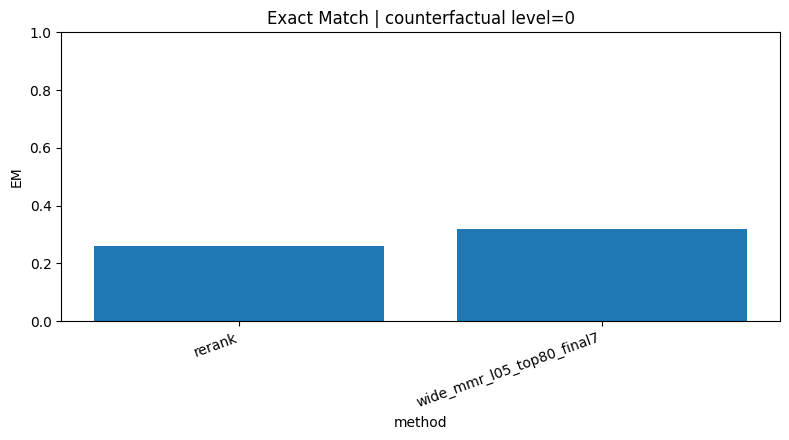

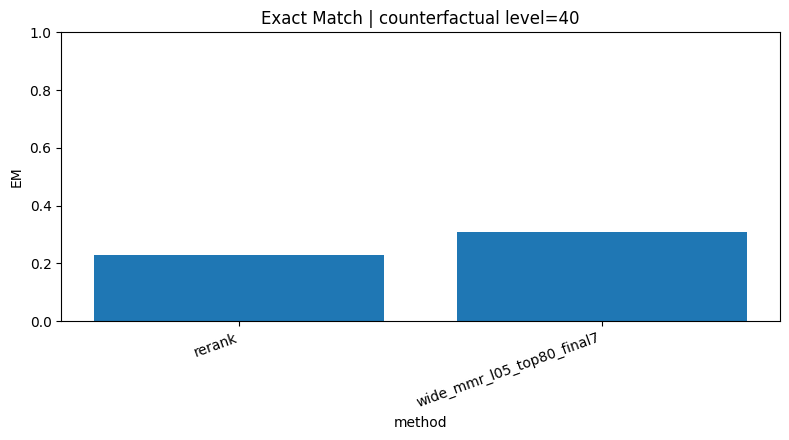

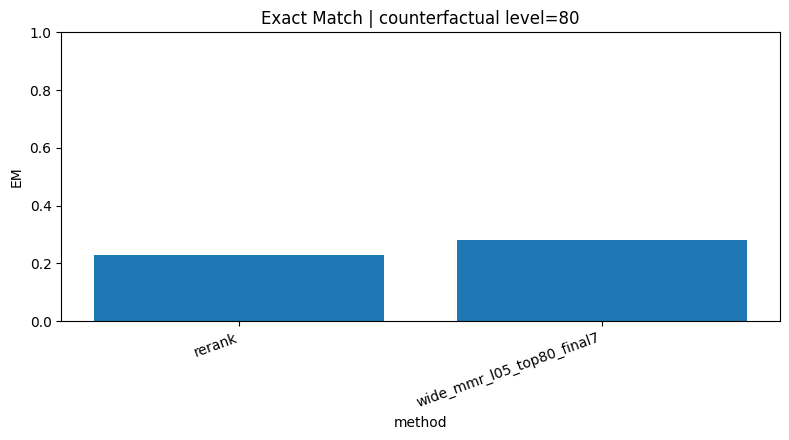

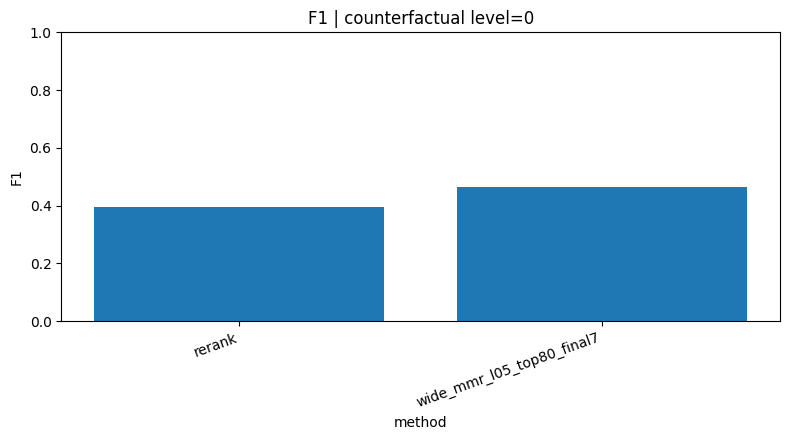

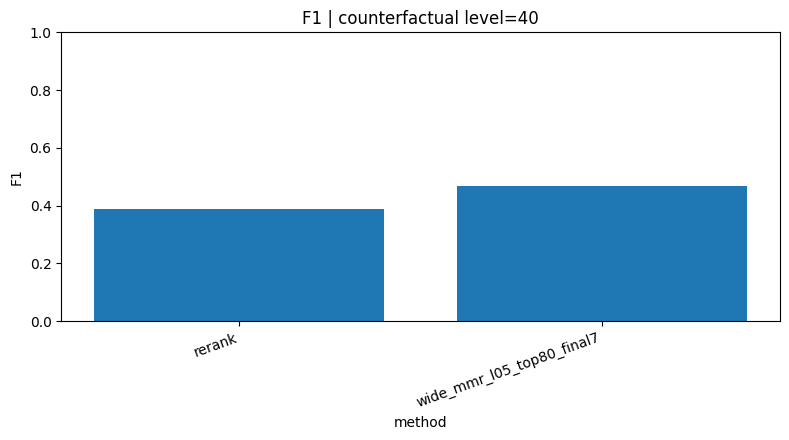

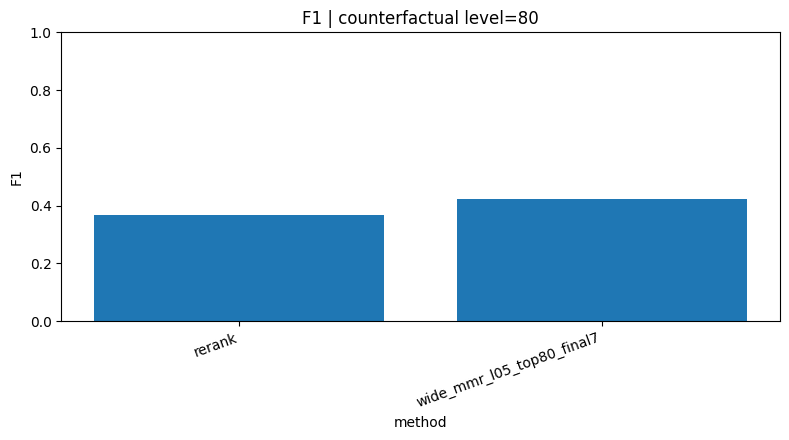

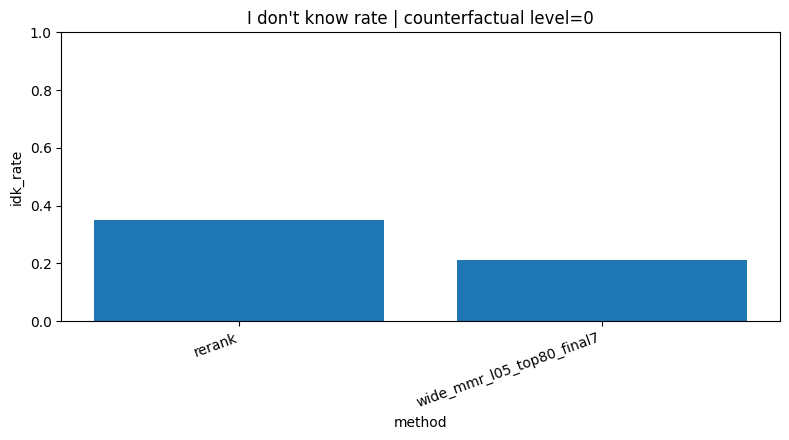

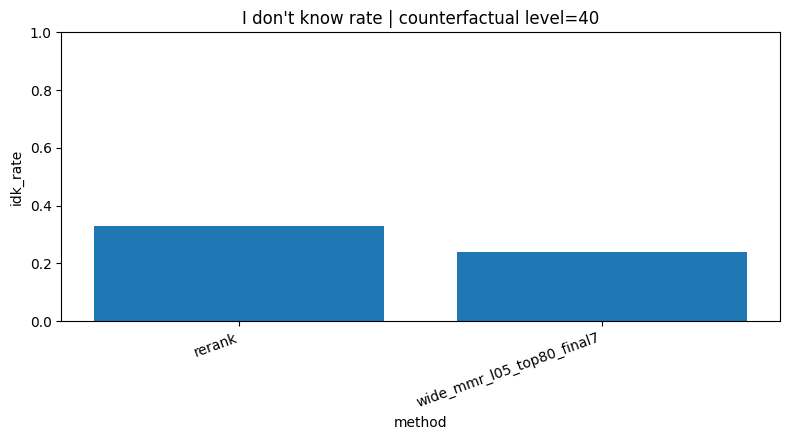

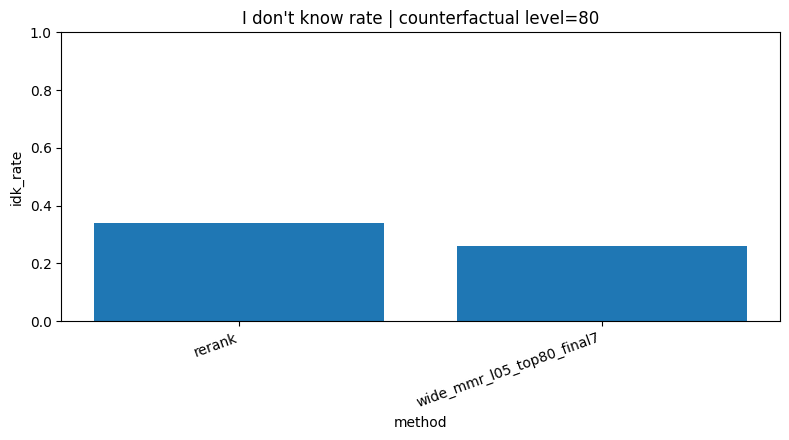

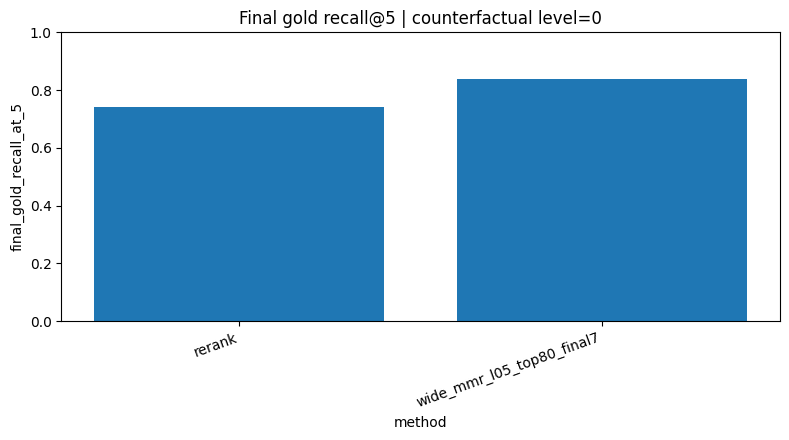

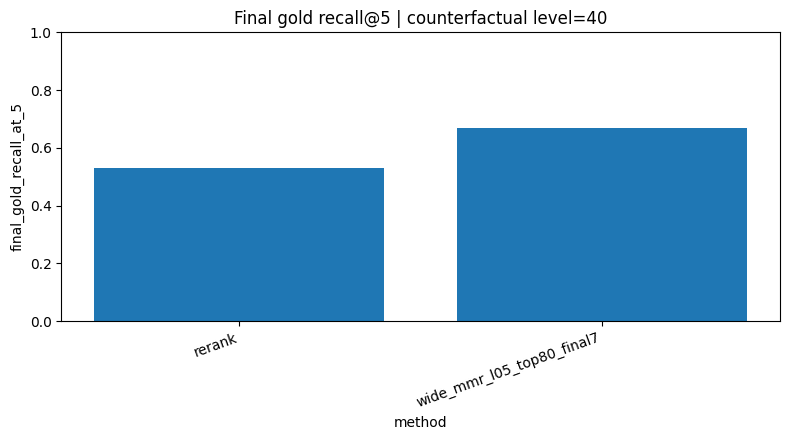

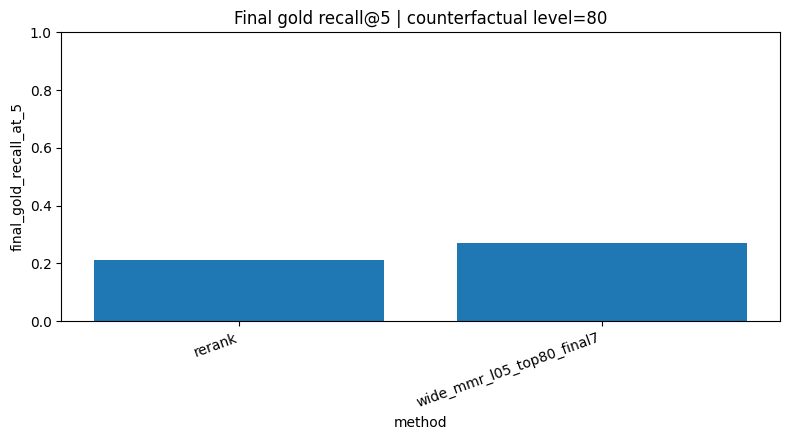

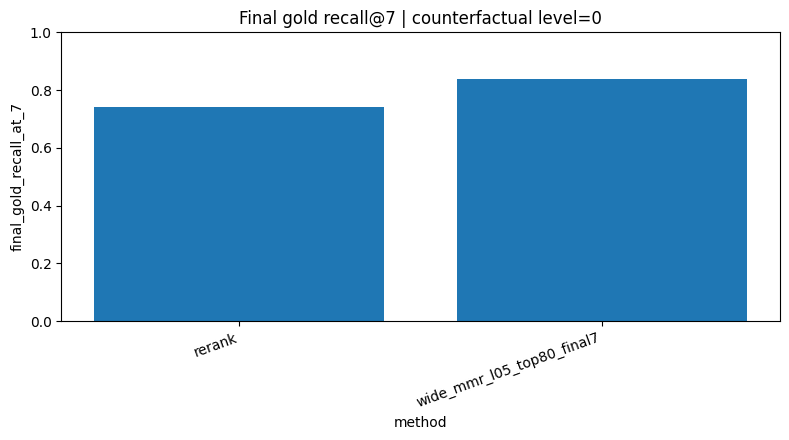

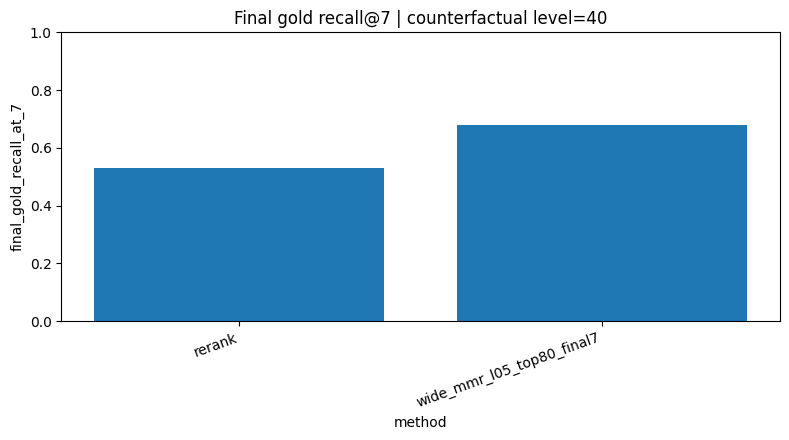

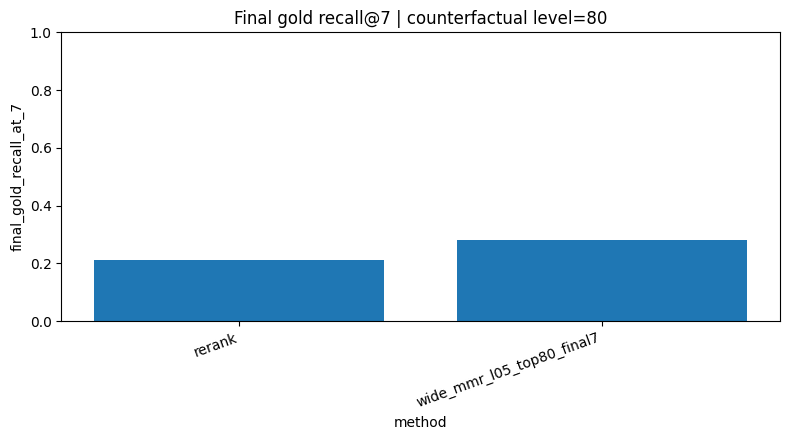

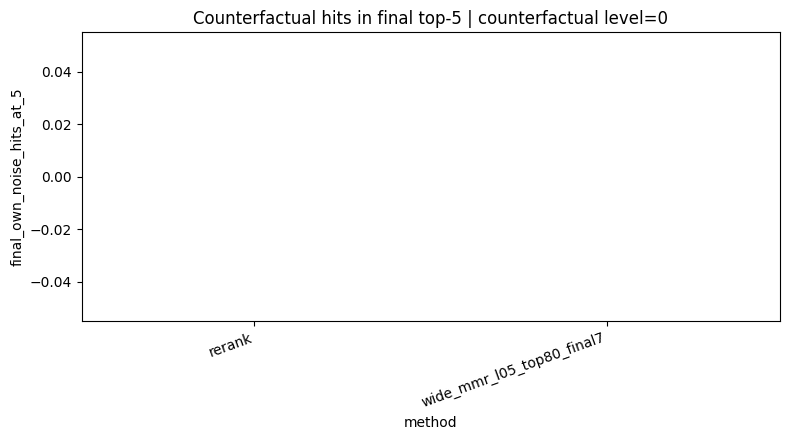

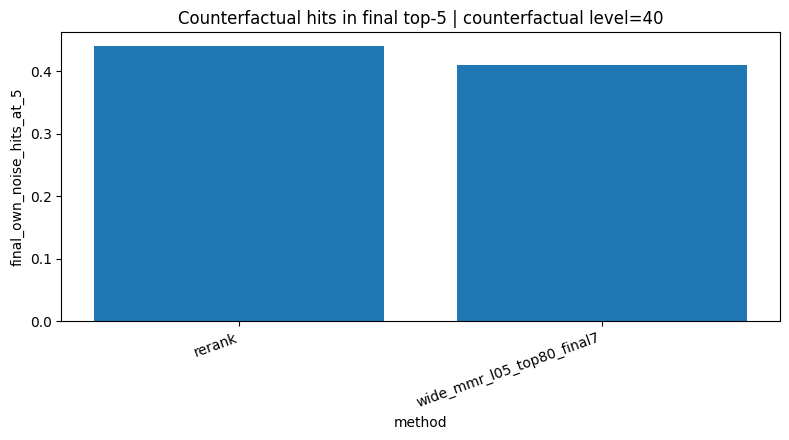

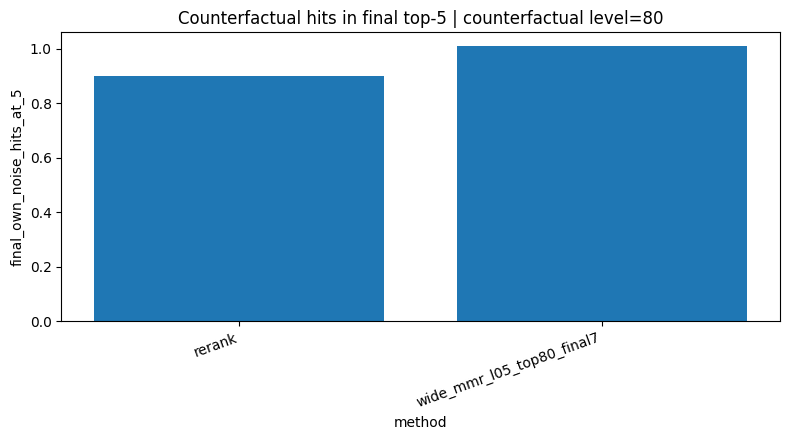

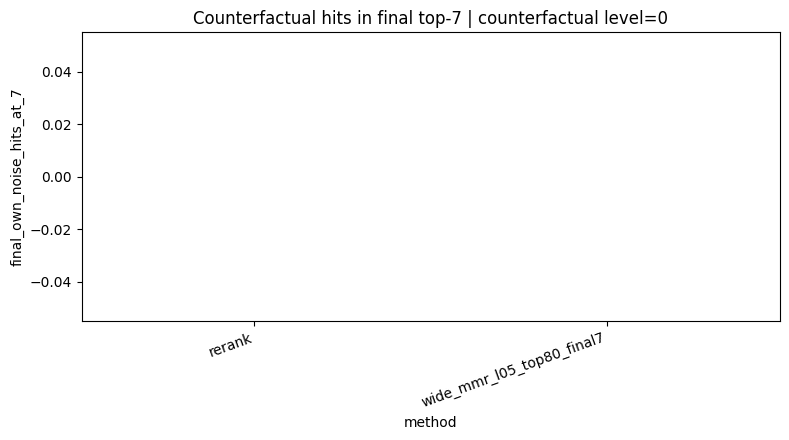

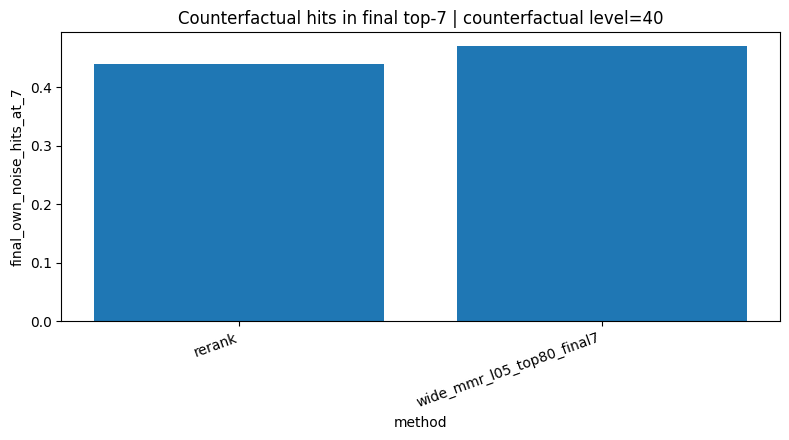

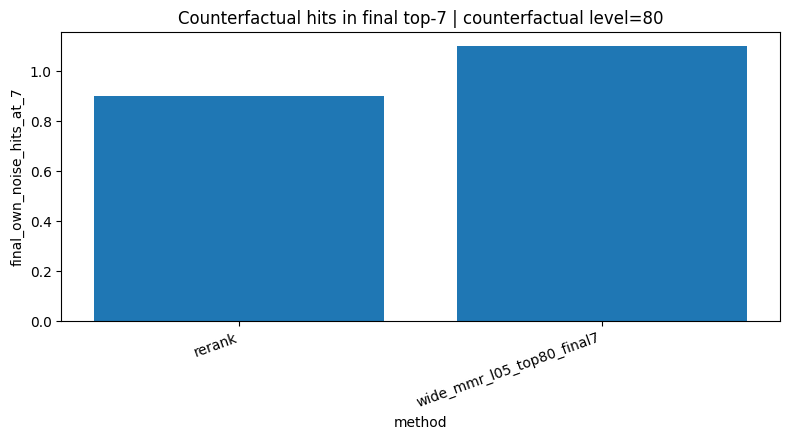

In [56]:
def plot_metric(summary_df: pd.DataFrame, metric: str, title: str, ylim=None):
    for lvl in sorted(summary_df["noise_level"].dropna().unique()):
        data = summary_df[summary_df["noise_level"] == lvl].copy()
        data = data.sort_values("method")

        plt.figure(figsize=(8, 4.5))
        plt.bar(data["method"], data[metric])
        plt.title(f"{title} | counterfactual level={lvl}")
        plt.xlabel("method")
        plt.ylabel(metric)
        if ylim is not None:
            plt.ylim(*ylim)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.show()

plot_metric(summary, "EM", "Exact Match", ylim=(0, 1))
plot_metric(summary, "F1", "F1", ylim=(0, 1))
plot_metric(summary, "idk_rate", "I don't know rate", ylim=(0, 1))
plot_metric(summary, "final_gold_recall_at_5", "Final gold recall@5", ylim=(0, 1))
plot_metric(summary, "final_gold_recall_at_7", "Final gold recall@7", ylim=(0, 1))
plot_metric(summary, "final_own_noise_hits_at_5", "Counterfactual hits in final top-5")
plot_metric(summary, "final_own_noise_hits_at_7", "Counterfactual hits in final top-7")

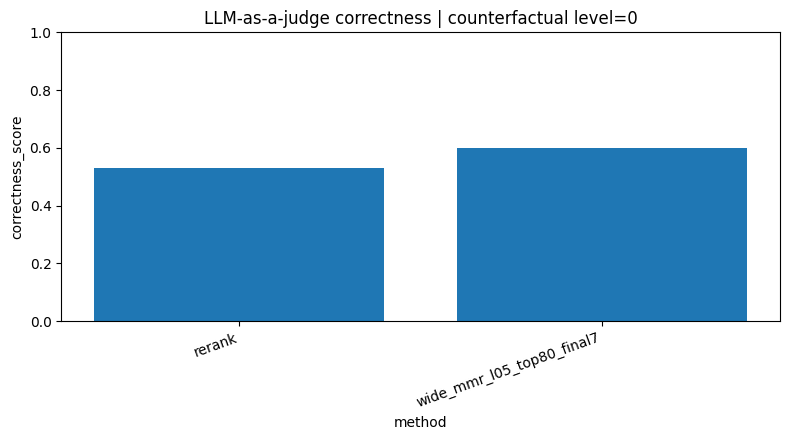

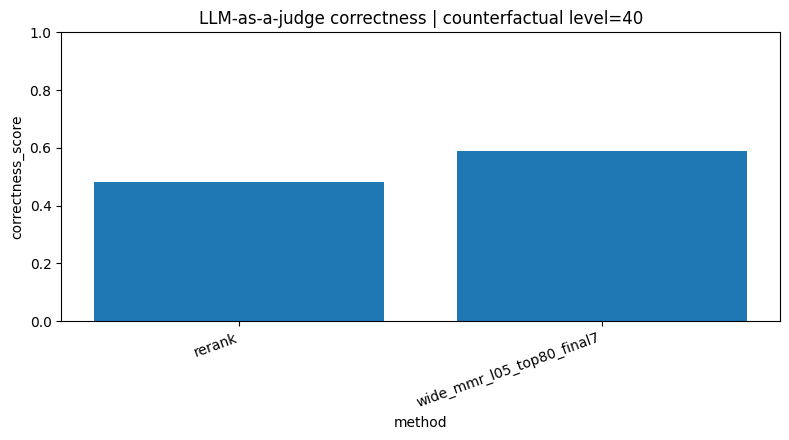

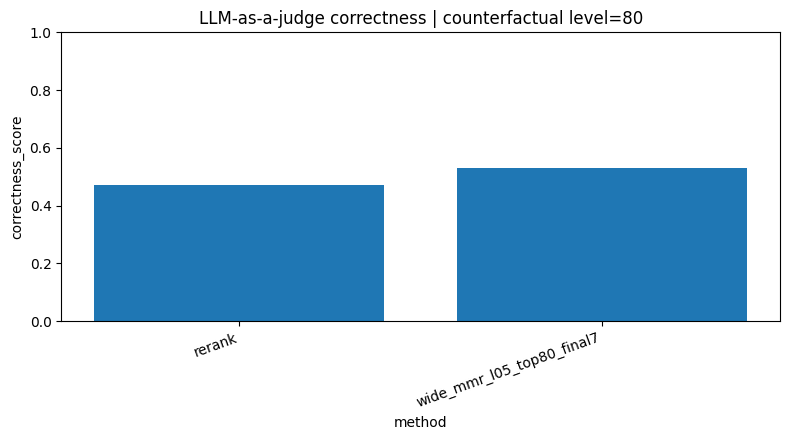

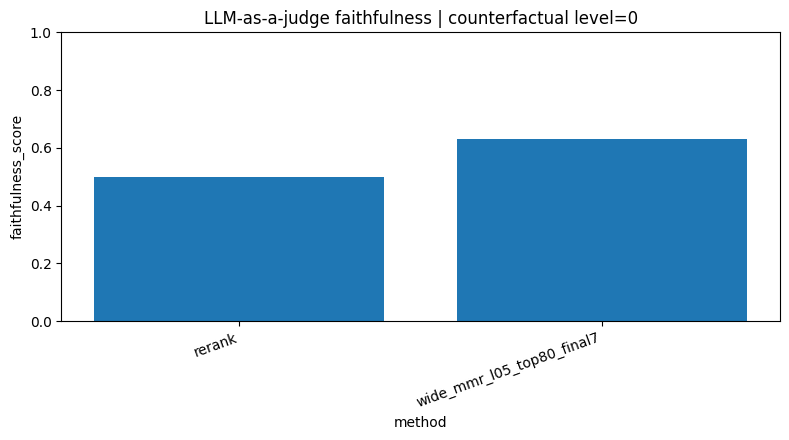

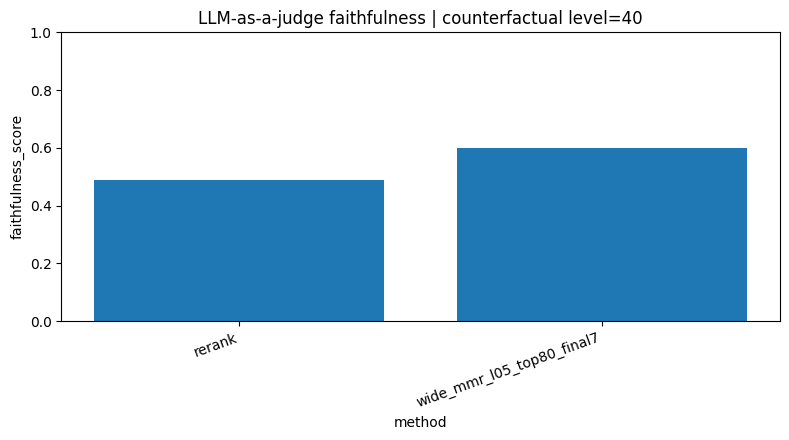

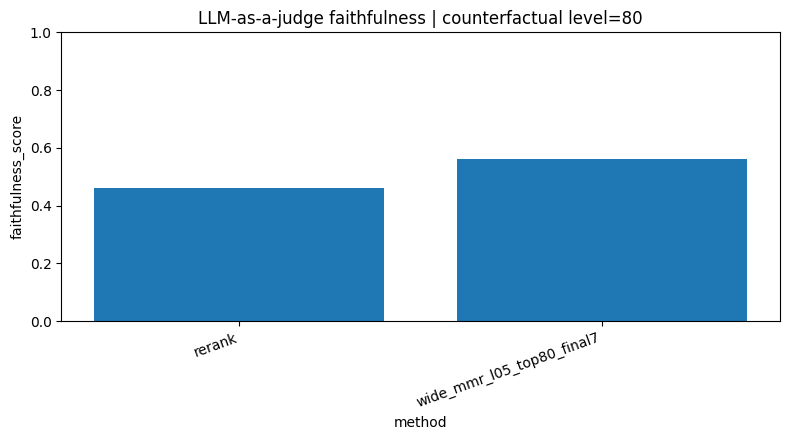

In [57]:
if "correctness_score" in summary.columns:
    plot_metric(summary, "correctness_score", "LLM-as-a-judge correctness", ylim=(0, 1))

if "faithfulness_score" in summary.columns:
    plot_metric(summary, "faithfulness_score", "LLM-as-a-judge faithfulness", ylim=(0, 1))

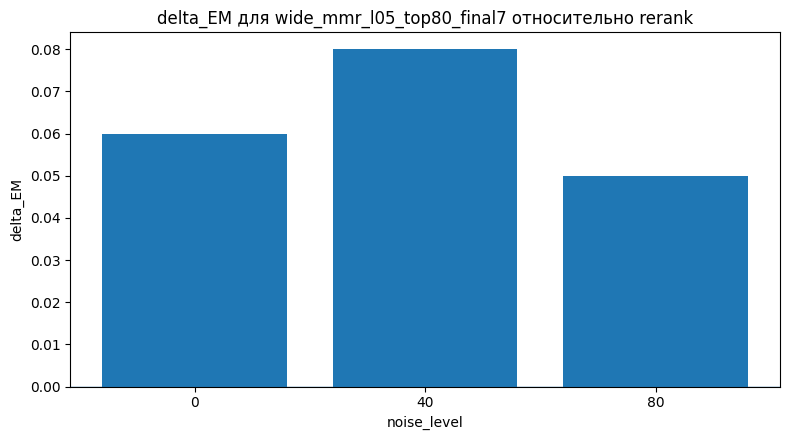

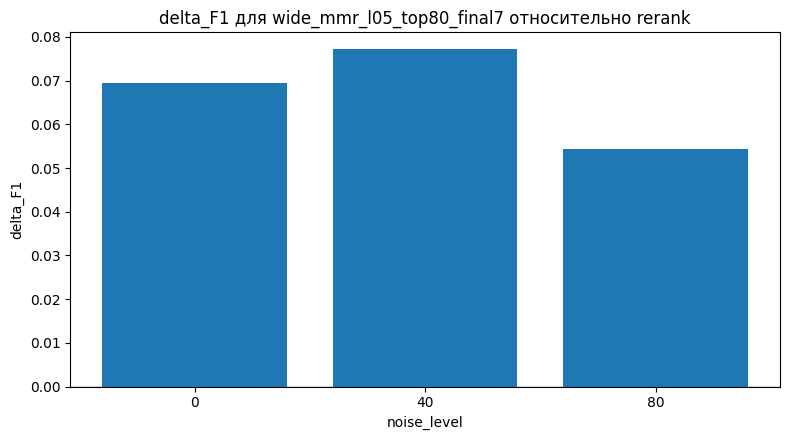

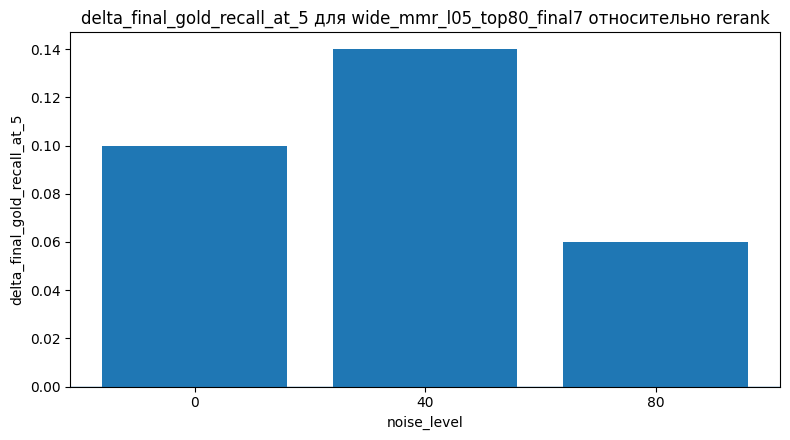

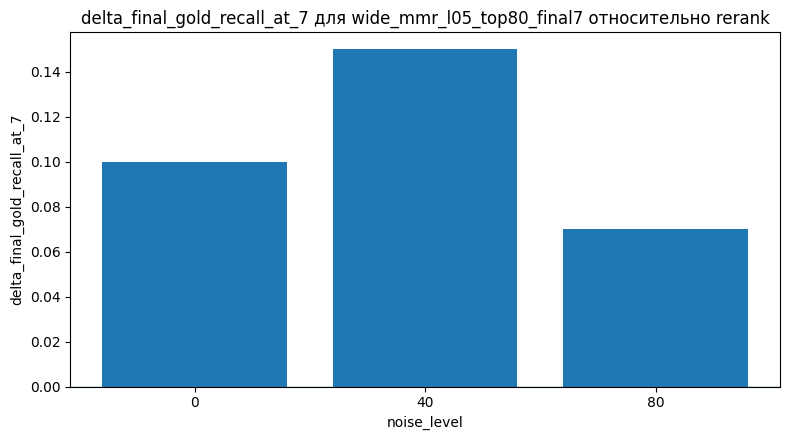

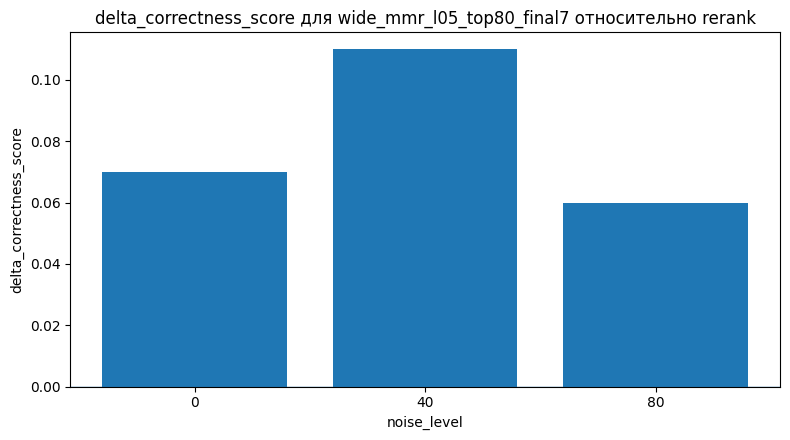

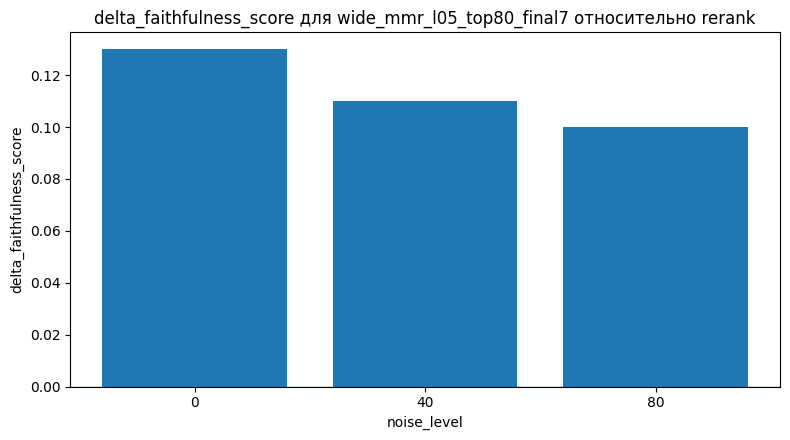

In [58]:
# Delta-графики для wide_mmr относительно rerank
wide = delta_df[delta_df["method"] != "rerank"].copy()

delta_metrics = ["delta_EM", "delta_F1", "delta_final_gold_recall_at_5", "delta_final_gold_recall_at_7"]

if "delta_correctness_score" in wide.columns:
    delta_metrics.append("delta_correctness_score")
if "delta_faithfulness_score" in wide.columns:
    delta_metrics.append("delta_faithfulness_score")

for metric in delta_metrics:
    plt.figure(figsize=(8, 4.5))
    data = wide.sort_values("noise_level")
    plt.bar(data["noise_level"].astype(str), data[metric])
    plt.axhline(0, linewidth=1)
    plt.title(f"{metric} для wide_mmr_l05_top80_final7 относительно rerank")
    plt.xlabel("noise_level")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

In [59]:
# Итоговая компактная таблица
cols = [
    "noise_level", "method", "n",
    "EM", "F1", "idk_rate",
    "final_gold_recall_at_5", "final_gold_recall_at_7",
    "final_own_noise_hits_at_5", "final_own_noise_hits_at_7",
]

if "correctness_score" in summary.columns:
    cols.append("correctness_score")
if "faithfulness_score" in summary.columns:
    cols.append("faithfulness_score")

display(summary[cols].sort_values(["noise_level", "method"]))

delta_cols = ["noise_level", "method", "delta_EM", "delta_F1", "delta_idk_rate", "delta_final_gold_recall_at_5", "delta_final_gold_recall_at_7"]
if "delta_correctness_score" in delta_df.columns:
    delta_cols.append("delta_correctness_score")
if "delta_faithfulness_score" in delta_df.columns:
    delta_cols.append("delta_faithfulness_score")

display(delta_df[delta_cols].sort_values(["noise_level", "method"]))

,noise_level,method,n,EM,F1,idk_rate,final_gold_recall_at_5,final_gold_recall_at_7,final_own_noise_hits_at_5,final_own_noise_hits_at_7,correctness_score,faithfulness_score
0,0,rerank,100,0.26,0.396179,0.35,0.74,0.74,0.00,0.00,0.53,0.50
1,0,wide_mmr_l05_top80_final7,100,0.32,0.465696,0.21,0.84,0.84,0.00,0.00,0.60,0.63
2,40,rerank,100,0.23,0.389115,0.33,0.53,0.53,0.44,0.44,0.48,0.49
3,40,wide_mmr_l05_top80_final7,100,0.31,0.466316,0.24,0.67,0.68,0.41,0.47,0.59,0.60
4,80,rerank,100,0.23,0.367711,0.34,0.21,0.21,0.90,0.90,0.47,0.46
5,80,wide_mmr_l05_top80_final7,100,0.28,0.421963,0.26,0.27,0.28,1.01,1.10,0.53,0.56


,noise_level,method,delta_EM,delta_F1,delta_idk_rate,delta_final_gold_recall_at_5,delta_final_gold_recall_at_7,delta_correctness_score,delta_faithfulness_score
0,0,rerank,0.00,0.000000,0.00,0.00,0.00,0.00,0.00
1,0,wide_mmr_l05_top80_final7,0.06,0.069518,-0.14,0.10,0.10,0.07,0.13
2,40,rerank,0.00,0.000000,0.00,0.00,0.00,0.00,0.00
3,40,wide_mmr_l05_top80_final7,0.08,0.077201,-0.09,0.14,0.15,0.11,0.11
4,80,rerank,0.00,0.000000,0.00,0.00,0.00,0.00,0.00
5,80,wide_mmr_l05_top80_final7,0.05,0.054252,-0.08,0.06,0.07,0.06,0.10


In [60]:
df.groupby(["noise_level", "method"])[["correctness_score", "faithfulness_score"]].agg(
    n_correctness=("correctness_score", "count"),
    n_faithfulness=("faithfulness_score", "count"),
    missing_correctness=("correctness_score", lambda x: x.isna().sum()),
    missing_faithfulness=("faithfulness_score", lambda x: x.isna().sum()),
)

n_correctness  n_faithfulness  \
noise_level method                                                     
0           rerank                               100             100   
            wide_mmr_l05_top80_final7            100             100   
40          rerank                               100             100   
            wide_mmr_l05_top80_final7            100             100   
80          rerank                               100             100   
            wide_mmr_l05_top80_final7            100             100   

                                       missing_correctness  \
noise_level method                                           
0           rerank                                       0   
            wide_mmr_l05_top80_final7                    0   
40          rerank                                       0   
            wide_mmr_l05_top80_final7                    0   
80          rerank                                       0   
            wide_mmr_l05_top80_final7                    0   

                                       missing_faithfulness  
noise_level method                                           
0           rerank                                        0  
            wide_mmr_l05_top80_final7                     0  
40          rerank                                        0  
            wide_mmr_l05_top80_final7                     0  
80          rerank                                        0  
            wide_mmr_l05_top80_final7                     0

## 10. Интерпретация

Для диплома в первую очередь смотри:

- `delta_F1`;
- `delta_correctness_score`;
- `delta_final_gold_recall_at_5/7`;
- `delta_faithfulness_score`.

Если `wide_mmr_l05_top80_final7` даёт положительный прирост на `counterfactual_40` и `counterfactual_80`, это можно оформить как специализированный метод повышения устойчивости к контрафактическому шуму.
